## Assignment 1: K-Nearest Neighbors Using NumPy Broadcasting

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
np.random.seed(0)
X = np.random.rand(10, 2)
print("Generated points:")
print(X)
print("\nShape of X:", X.shape)

Generated points:
[[0.5488135  0.71518937]
 [0.60276338 0.54488318]
 [0.4236548  0.64589411]
 [0.43758721 0.891773  ]
 [0.96366276 0.38344152]
 [0.79172504 0.52889492]
 [0.56804456 0.92559664]
 [0.07103606 0.0871293 ]
 [0.0202184  0.83261985]
 [0.77815675 0.87001215]]

Shape of X: (10, 2)


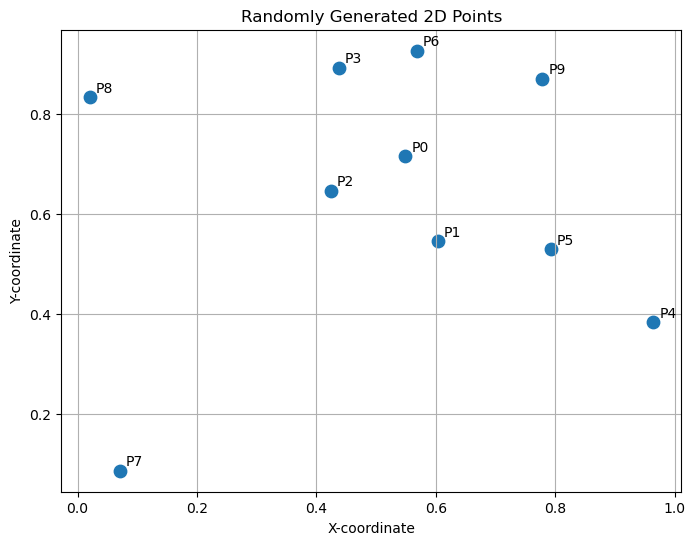

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=80)
for i, (x, y) in enumerate(X):
    plt.text(x + 0.01, y + 0.01, f"P{i}")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("Randomly Generated 2D Points")
plt.grid(True)
plt.show()

In [9]:
D2 = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)
print("Pairwise squared distance matrix:")
print(D2)
print("Shape of D2:", D2.shape)

Pairwise squared distance matrix:
[[0.         0.03191478 0.02046653 0.04355307 0.28215654 0.09371163
  0.04464105 0.62273073 0.2932027  0.07656842]
 [0.03191478 0.         0.04228309 0.14761571 0.15631178 0.03596213
  0.14614813 0.49227256 0.42215104 0.13647168]
 [0.02046653 0.04228309 0.         0.06065054 0.36048996 0.14916451
  0.09908191 0.43655809 0.19762743 0.17590053]
 [0.04355307 0.14761571 0.06065054 0.         0.53515638 0.2570941
  0.01816316 0.78181123 0.17769582 0.11646115]
 [0.28215654 0.15631178 0.36048996 0.53515638 0.         0.05071927
  0.45044593 0.88458336 1.09184844 0.27116346]
 [0.09371163 0.03596213 0.14916451 0.2570941  0.05071927 0.
  0.20740521 0.71454947 0.68747133 0.11654506]
 [0.04464105 0.14614813 0.09908191 0.01816316 0.45044593 0.20740521
  0.         0.95004493 0.30875819 0.04723677]
 [0.62273073 0.49227256 0.43655809 0.78181123 0.88458336 0.71454947
  0.95004493 0.         0.55833859 1.11292523]
 [0.2932027  0.42215104 0.19762743 0.17769582 1.0918484

In [10]:
coordinate_diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
print("Step 1 - Coordinate differences shape:",coordinate_diff.shape)
squared_diff = coordinate_diff ** 2
print("Step 2 - Squared differences shape:",squared_diff.shape)
summed_squared_distances = np.sum(squared_diff, axis=2)
print("Step 3 - Summed squared distances shape:",summed_squared_distances.shape)

Step 1 - Coordinate differences shape: (10, 10, 2)
Step 2 - Squared differences shape: (10, 10, 2)
Step 3 - Summed squared distances shape: (10, 10)


In [11]:
diagonal = np.diag(D2)
print("Diagonal of the distance matrix:")
print(diagonal)
print("\nAre all diagonal values zero?",np.allclose(diagonal, 0))

Diagonal of the distance matrix:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Are all diagonal values zero? True


In [12]:
neighbor_order = np.argsort(D2, axis=1)
print("Neighbor ordering for each point:")
print(neighbor_order)
print("\nFirst column:")
print(neighbor_order[:, 0])

Neighbor ordering for each point:
[[0 2 1 3 6 9 5 4 8 7]
 [1 0 5 2 9 6 3 4 8 7]
 [2 0 1 3 6 5 9 8 4 7]
 [3 6 0 2 9 1 8 5 4 7]
 [4 5 1 9 0 2 6 3 7 8]
 [5 1 4 0 9 2 6 3 8 7]
 [6 3 0 9 2 1 5 8 4 7]
 [7 2 1 8 0 5 3 4 6 9]
 [8 3 2 0 6 1 7 9 5 4]
 [9 6 0 3 5 1 2 4 8 7]]

First column:
[0 1 2 3 4 5 6 7 8 9]


In [13]:
K = 2
nearest_using_argsort = neighbor_order[:, 1:K+1]
print("Two nearest neighbors using argsort:")
print(nearest_using_argsort)

Two nearest neighbors using argsort:
[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]


In [14]:
K = 2
candidate_indices = np.argpartition(D2,K + 1,axis=1)[:, :K + 1]
print("K+1 candidate indices:")
print(candidate_indices)

K+1 candidate indices:
[[0 2 1]
 [1 0 5]
 [0 2 1]
 [3 6 0]
 [1 4 5]
 [1 4 5]
 [3 0 6]
 [1 7 2]
 [8 3 2]
 [6 9 0]]


In [15]:
candidate_distances = np.take_along_axis(D2,candidate_indices,axis=1)
candidate_order = np.argsort(candidate_distances,axis=1)
sorted_candidates = np.take_along_axis(candidate_indices,candidate_order,axis=1)
nearest_neighbors = sorted_candidates[:, 1:K+1]
print("Two nearest neighbors using argpartition:")
print(nearest_neighbors)

Two nearest neighbors using argpartition:
[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]


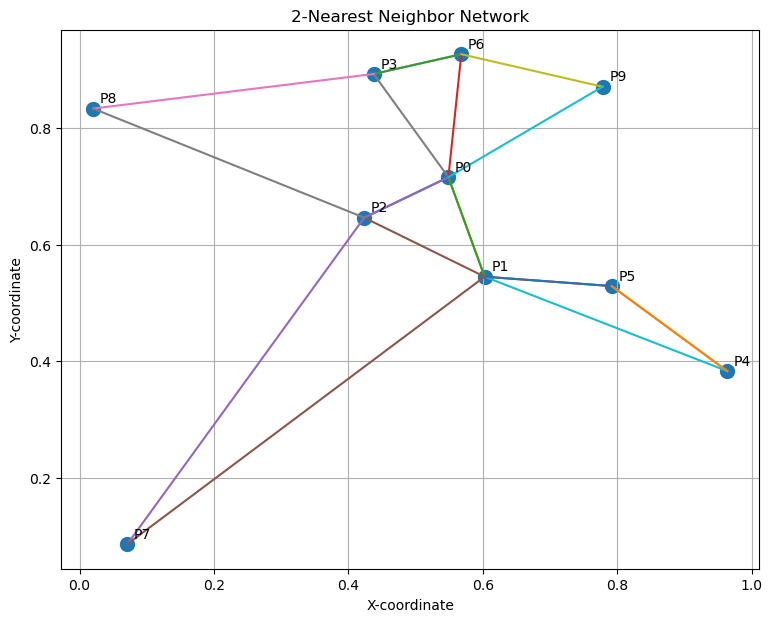

In [16]:
plt.figure(figsize=(9, 7))
plt.scatter(X[:, 0],X[:, 1],s=100)
for i, (x, y) in enumerate(X):
    plt.text(x + 0.01,y + 0.01,f"P{i}")
for i in range(len(X)):
    for j in nearest_neighbors[i]:
        x1, y1 = X[i]
        x2, y2 = X[j]
        plt.plot([x1, x2],[y1, y2])
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("2-Nearest Neighbor Network")
plt.grid(True)
plt.show()

In [17]:
def loop_based_neighbors(X, K=2):
    """Calculate K nearest neighbors using Python loops."""
    N = len(X)
    distances = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            difference = X[i] - X[j]
            distances[i, j] = np.sum(difference ** 2)
    neighbors = np.zeros((N, K), dtype=int)
    for i in range(N):
        order = np.argsort(distances[i])
        neighbors[i] = order[1:K+1]
    return neighbors

In [18]:
def vectorized_neighbors(X, K=2):
    """Calculate K nearest neighbors using NumPy broadcasting."""
    D2 = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2,axis=2)
    candidates = np.argpartition(D2,K + 1,axis=1)[:, :K + 1]
    candidate_distances = np.take_along_axis(D2,candidates,axis=1)
    order = np.argsort(candidate_distances,axis=1)
    sorted_candidates = np.take_along_axis(candidates,order,axis=1)
    return sorted_candidates[:, 1:K+1]

In [19]:
X_test = np.random.rand(10, 2)
loop_result = loop_based_neighbors(X_test)
vectorized_result = vectorized_neighbors(X_test)
print("Loop-based result:")
print(loop_result)
print("\nVectorized result:")
print(vectorized_result)
print("\nAre both results identical?",np.array_equal(loop_result, vectorized_result))

Loop-based result:
[[9 8]
 [5 6]
 [7 5]
 [5 2]
 [6 8]
 [1 2]
 [8 4]
 [2 5]
 [6 4]
 [0 8]]

Vectorized result:
[[9 8]
 [5 6]
 [7 5]
 [5 2]
 [6 8]
 [1 2]
 [8 4]
 [2 5]
 [6 4]
 [0 8]]

Are both results identical? True


In [20]:
X_100 = np.random.rand(100, 2)
print("Vectorized version for N = 100:")
%timeit vectorized_neighbors(X_100)
print("\nLoop-based version for N = 100:")
%timeit loop_based_neighbors(X_100)

Vectorized version for N = 100:
571 μs ± 71.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

Loop-based version for N = 100:
95 ms ± 3.25 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [21]:
X_1000 = np.random.rand(1000, 2)
print("Vectorized version for N = 1000:")
%timeit vectorized_neighbors(X_1000)
print("\nLoop-based version for N = 1000:")
%timeit loop_based_neighbors(X_1000)

Vectorized version for N = 1000:
72.2 ms ± 2.28 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Loop-based version for N = 1000:
10.6 s ± 1.47 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [22]:
X_5000 = np.random.rand(5000, 2)
print("Vectorized version for N = 5000:")
%timeit vectorized_neighbors(X_5000)
print("\nLoop-based version for N = 5000:")
%timeit loop_based_neighbors(X_5000)

Vectorized version for N = 5000:
1.85 s ± 155 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Loop-based version for N = 5000:
7min 9s ± 4min 40s per loop (mean ± std. dev. of 7 runs, 1 loop each)
